# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

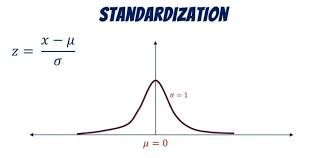


In [50]:
import os
import numpy as np

if not os.path.exists("API_16_DS2_en_csv_v2_264259.csv"):
    !git clone https://github.com/garangbse/PCA_Formative-Team_48.git
    %cd PCA_Formative-Team_48

filename = "API_16_DS2_en_csv_v2_264259.csv"
data = np.genfromtxt(
    filename,
    delimiter='","',
    skip_header=4,
    dtype=str,
    encoding='utf-8'
)

clean_str = np.vectorize(lambda x: x.strip().strip(',').strip('"').strip("'"))
data = clean_str(data)

print("Raw parsed data shape:", data.shape)
print("Header row sample:", data[0, :6])
print("First data row sample:", data[1, :6])

Raw parsed data shape: (4523, 70)
Header row sample: ['Country Name' 'Country Code' 'Indicator Name' 'Indicator Code' '1960'
 '1961']
First data row sample: ['Aruba' 'ABW' 'Urban population (% of total population)'
 'SP.URB.TOTL.IN.ZS' '59.0236701687155' '59.0727998569268']


In [51]:
headers = data[0]
raw_data = data[1:]

indicator_code = "EN.POP.DNST"
african_iso3 = [
    "DZA", "AGO", "BEN", "BWA", "BFA", "BDI", "CPV", "CMR", "CAF", "TCD",
    "COM", "COD", "COG", "DJI", "EGY", "GNQ", "ERI", "SWZ", "ETH", "GAB",
    "GMB", "GHA", "GIN", "GNB", "CIV", "KEN", "LSO", "LBR", "LBY", "MDG",
    "MWI", "MLI", "MRT", "MUS", "MAR", "MOZ", "NAM", "NER", "NGA", "RWA",
    "STP", "SEN", "SYC", "SLE", "SOM", "ZAF", "SSD", "SDN", "TZA", "TGO",
    "TUN", "UGA", "ZMB", "ZWE"
]

selected = raw_data[(raw_data[:, 3] == indicator_code) & np.isin(raw_data[:, 1], african_iso3)]

non_numeric_cols = headers[:4]
country_names = selected[:, 0]
_, encoded_country_code = np.unique(selected[:, 1], return_inverse=True)
year_headers = headers[4:]

def to_float(val):
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

year_numeric_data = np.vectorize(to_float)(selected[:, 4:]).astype(float)

initial_cols = year_numeric_data.shape[1]
valid_cols = ~np.all(np.isnan(year_numeric_data), axis=0)
dropped_cols = year_headers[~valid_cols]
year_numeric_data = year_numeric_data[:, valid_cols]
valid_years = year_headers[valid_cols]

initial_nan_count = int(np.sum(np.isnan(year_numeric_data)))

col_means_nan = np.nanmean(year_numeric_data, axis=0)
nan_idx = np.where(np.isnan(year_numeric_data))
year_numeric_data[nan_idx] = np.take(col_means_nan, nan_idx[1])

numeric_data = np.column_stack([year_numeric_data, encoded_country_code.astype(float)])
feature_names = np.append(valid_years, "Encoded_Country_Code")

means = np.mean(numeric_data, axis=0)
stds = np.std(numeric_data, axis=0)
stds[stds == 0] = 1

standardized_data = (numeric_data - means) / stds

print("Non-numeric columns identified:", [str(c) for c in non_numeric_cols])
print("Encoded 'Country Code' column added to PCA matrix (first 5):", encoded_country_code[:5])
print("Constant non-numeric columns excluded:", [str(c) for c in non_numeric_cols[2:]])
print("African countries selected:", selected.shape[0])
print("Initial year columns:", initial_cols)
print("Completely empty columns removed:", int(np.sum(~valid_cols)), "->", [str(c) for c in dropped_cols])
print("Missing (NaN) values identified before imputation:", initial_nan_count)
print("Missing (NaN) values remaining after mean imputation:", int(np.sum(np.isnan(numeric_data))))
print(f"Final PCA feature matrix shape: {standardized_data.shape} ({len(valid_years)} years + 1 encoded column)")
print("Mean per feature (~0):", np.round(standardized_data.mean(axis=0)[:5], 4))
print("Std per feature (~1):", np.round(standardized_data.std(axis=0)[:5], 4))

standardized_data[:5]

Non-numeric columns identified: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
Encoded 'Country Code' column added to PCA matrix (first 5): [0 1 2 3 4]
Constant non-numeric columns excluded: ['Indicator Name', 'Indicator Code']
African countries selected: 54
Initial year columns: 66
Completely empty columns removed: 3 -> ['1960', '2024', '2025']
Missing (NaN) values identified before imputation: 166
Missing (NaN) values remaining after mean imputation: 0
Final PCA feature matrix shape: (54, 64) (63 years + 1 encoded column)
Mean per feature (~0): [-0. -0. -0. -0.  0.]
Std per feature (~1): [1. 1. 1. 1. 1.]


array([[-0.5278, -0.5275, -0.5279, -0.5287, -0.53  , -0.532 , -0.5348,
        -0.5382, -0.5417, -0.5451, -0.5477, -0.5497, -0.5514, -0.5535,
        -0.556 , -0.5585, -0.561 , -0.5643, -0.5665, -0.5687, -0.5714,
        -0.5743, -0.5779, -0.5814, -0.5855, -0.5897, -0.5947, -0.5993,
        -0.6037, -0.6075, -0.6102, -0.612 , -0.599 , -0.6058, -0.6106,
        -0.6114, -0.6099, -0.6115, -0.6134, -0.6157, -0.6188, -0.6222,
        -0.6243, -0.6232, -0.6248, -0.6267, -0.6283, -0.6301, -0.6313,
        -0.6324, -0.6299, -0.6021, -0.6025, -0.6029, -0.6037, -0.6045,
        -0.6048, -0.6049, -0.6047, -0.6047, -0.6046, -0.6072, -0.6079,
        -1.7003],
       [ 1.5727,  1.571 ,  1.564 ,  1.5747,  1.5854,  1.5899,  1.5973,
         1.6021,  1.6034,  1.6057,  1.6149,  1.5745,  1.5328,  1.5438,
         1.5526,  1.556 ,  1.5656,  1.5874,  1.5951,  1.6398,  1.6848,
         1.6996,  1.7226,  1.7372,  1.7479,  1.7528,  1.7629,  1.7755,
         1.7814,  1.7925,  1.8011,  1.8234,  1.7148,  1.752

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [52]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data.T)
print("Covariance matrix shape:", cov_matrix.shape)
cov_matrix

Covariance matrix shape: (64, 64)


array([[1.0189, 1.0189, 1.0188, ..., 0.8908, 0.882 , 0.0652],
       [1.0189, 1.0189, 1.0189, ..., 0.8898, 0.8809, 0.0651],
       [1.0188, 1.0189, 1.0189, ..., 0.8888, 0.8799, 0.0651],
       ...,
       [0.8908, 0.8898, 0.8888, ..., 1.0189, 1.0187, 0.0127],
       [0.882 , 0.8809, 0.8799, ..., 1.0187, 1.0189, 0.0106],
       [0.0652, 0.0651, 0.0651, ..., 0.0127, 0.0106, 1.0189]])

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

We compute a covariance matrix to quantify how different features (years of population density) vary together across countries, allowing us to detect strong linear correlations and data redundancy. Second, it provides the mathematical foundation for eigendecomposition, enabling us to extract the eigenvectors (principal components) that point in the orthogonal directions of maximum variance in the dataset.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [53]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)
eigenvalues, eigenvectors

Eigenvalues shape: (64,)
Eigenvectors shape: (64, 64)


(array([62.4141+0.j,  1.6358+0.j,  0.9883+0.j,  0.0972+0.j,  0.0426+0.j,
         0.0132+0.j,  0.0069+0.j,  0.0047+0.j,  0.0016+0.j,  0.0012+0.j,
         0.001 +0.j,  0.0004+0.j,  0.0002+0.j,  0.0001+0.j,  0.0001+0.j,
         0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,
         0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,
         0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,
         0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,
         0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,
         0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,
         0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j,
         0.    +0.j,  0.    +0.j,  0.    +0.j, -0.    +0.j, -0.    +0.j,
        -0.    +0.j, -0.    +0.j,  0.    +0.j,  0.    -0.j,  0.    +0.j,
        -0.    +0.j,  0.    +0.j,  0.    +0.j,  0.    +0.j]),
 array([[-0.1254+0.j,  0.1429+0.j, -0.0444+0.j, ..., -0.0607+0

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

Explained variance measures the exact proportion of the dataset's total information (variance) captured by each individual principal component, calculated as the ratio of its eigenvalue to the sum of all eigenvalues. In PCA, we use cumulative explained variance to rank components by importance and dynamically select the optimal number of dimensions to retain (here, keeping PC1 and PC2 to preserve 98.22% of total variance across all 64 features) while discarding low-variance noise

In [54]:
# Step 5: Sort Principal Components
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = np.maximum(eigenvalues[sorted_indices], 0)
sorted_eigenvectors = eigenvectors[:, sorted_indices]

signs = np.sign(sorted_eigenvectors[62, :])
signs[signs == 0] = 1
sorted_eigenvectors = sorted_eigenvectors * signs

explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
explained_variance_per = explained_variance * 100
cumulative_explained_variance = np.cumsum(explained_variance_per)

np.set_printoptions(suppress=True, precision=4)
print("Top 10 Sorted Eigenvalues:")
print(np.round(sorted_eigenvalues[:10], 4))

print("\nExplained Variance (%):")
print(np.round(explained_variance_per, 2))

print("\nCumulative Explained Variance (%):")
print(np.round(cumulative_explained_variance, 2))

sorted_eigenvectors

Top 10 Sorted Eigenvalues:
[62.4141  1.6358  0.9883  0.0972  0.0426  0.0132  0.0069  0.0047  0.0016
  0.0012]

Explained Variance (%):
[95.72  2.51  1.52  0.15  0.07  0.02  0.01  0.01  0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.  ]

Cumulative Explained Variance (%):
[ 95.72  98.22  99.74  99.89  99.95  99.97  99.99  99.99 100.   100.
 100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.   100.   100.   100.  ]


array([[ 0.1254, -0.1429, -0.0444, ...,  0.011 , -0.0386, -0.0545],
       [ 0.1253, -0.1445, -0.0451, ...,  0.0091,  0.0186,  0.0956],
       [ 0.1253, -0.146 , -0.0457, ..., -0.024 ,  0.0734, -0.0139],
       ...,
       [ 0.1211,  0.2425,  0.0506, ...,  0.0022, -0.0069, -0.0199],
       [ 0.1204,  0.2554,  0.0538, ...,  0.0027,  0.0131,  0.0228],
       [ 0.0069, -0.2255,  0.9712, ..., -0.    , -0.    ,  0.    ]])

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [55]:
# Step 6: Project Data onto Principal Components
variance_threshold = 98.0
num_components = int(np.argmax(cumulative_explained_variance >= variance_threshold) + 1)
selected_components = sorted_eigenvectors[:, :num_components]
reduced_data = np.dot(standardized_data, selected_components)

print(f"Dynamically selected components (>= {variance_threshold}% variance): {num_components}")
print(f"Cumulative variance retained: {cumulative_explained_variance[num_components - 1]:.2f}%")
reduced_data[:5]

Dynamically selected components (>= 98.0% variance): 2
Cumulative variance retained: 98.22%


array([[-4.6785,  0.1541],
       [15.4492,  3.7305],
       [-0.8846,  0.9748],
       [-2.2926,  0.4835],
       [-5.4439, -0.1904]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [56]:
# Step 7: Output the Reduced Data
print(f"Reduced Data Shape: {reduced_data.shape}")
reduced_data[:5]

Reduced Data Shape: (54, 2)


array([[-4.6785,  0.1541],
       [15.4492,  3.7305],
       [-0.8846,  0.9748],
       [-2.2926,  0.4835],
       [-5.4439, -0.1904]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

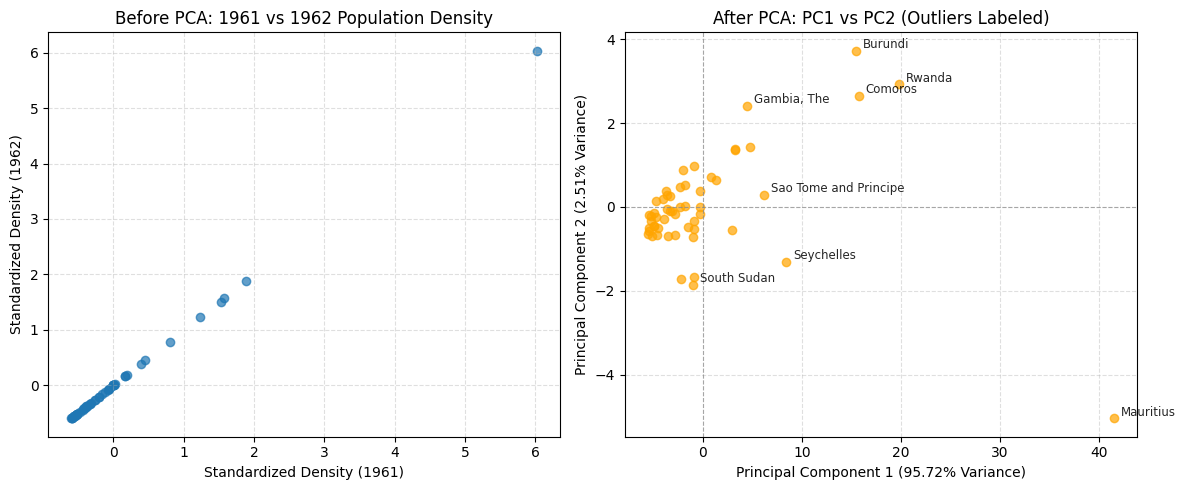

In [57]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(standardized_data[:, 0], standardized_data[:, 1], alpha=0.7)
plt.title(f"Before PCA: {valid_years[0]} vs {valid_years[1]} Population Density")
plt.xlabel(f"Standardized Density ({valid_years[0]})")
plt.ylabel(f"Standardized Density ({valid_years[1]})")
plt.grid(True, linestyle='--', alpha=0.4)

plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.7, color='orange')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

for i, country in enumerate(country_names):
    if reduced_data[i, 0] > 5 or abs(reduced_data[i, 1]) > 1.85:
        plt.annotate(
            country,
            (reduced_data[i, 0], reduced_data[i, 1]),
            fontsize=8.5,
            alpha=0.85,
            xytext=(5, 2),
            textcoords='offset points'
        )

plt.title("After PCA: PC1 vs PC2 (Outliers Labeled)")
plt.xlabel(f"Principal Component 1 ({explained_variance_per[0]:.2f}% Variance)")
plt.ylabel(f"Principal Component 2 ({explained_variance_per[1]:.2f}% Variance)")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

Before PCA, plotting 1961 against 1962 population density forms a tight diagonal line because consecutive years are almost identical and highly correlated. After PCA, the 64 features are rotated onto PC1 (95.72% variance, showing overall density size and separating high-density outliers like Mauritius, Rwanda, and Burundi from low-density countries) and PC2 (2.51% variance, showing long-term density growth rates where rapidly growing countries sit well above 0).

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

We dynamically selected 2 principal components using a 98% threshold because PC1 (95.72%) and PC2 (2.51%) together capture 98.22% of the total variance across all 64 features. The tradeoff is dropping the remaining 1.78% of variance in PC3–PC64, giving up minor year-by-year precision in exchange for compressing 64 columns into 2 dimensions for clear visualization and faster computation.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

In our African population pressure (population density) dataset, reducing 64 dimensions to 2 loses the 1.78% of variance stored in PC3–PC64, which consists of the uncorrelated label-encoded country ID variance (isolated in PC3 at 1.52%) and minor single-year demographic fluctuations (0.26%). While multi-decade national density averages and growth trajectories are preserved, short-term year-to-year shifts from migration, border changes, or census adjustments are smoothed out
